# CINIC-10 CNN Experiment

This notebook contains analysis of different model performance



In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator

### Paths

In [9]:
DATA_DIR = "/content"

PROJECT_DIR = "/content/drive/MyDrive/DLprojekt1"

MODEL_DIR = os.path.join(PROJECT_DIR, "saved_models")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
RESULT_DIR = os.path.join(PROJECT_DIR, "results")
PLOT_DIR = os.path.join(PROJECT_DIR, "plots")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

### Plot functions

In [10]:
def plot_training_params(data_dir, lr_files, opt_files, save_file_name):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # ===== LEARNING RATE =====
    colors = ["#264653", "#2A9D8F", "#E9C46A"]

    for (label, file), color in zip(lr_files.items(), colors):
        df = pd.read_csv(os.path.join(data_dir, file))
        ax1.plot(df["epoch"], df["train_loss"], color=color, label=label)
        ax1.plot(df["epoch"], df["val_loss"], linestyle="--", color=color)

    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.set_title("Learning Rate")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ===== OPTIMIZER =====
    for (label, file), color in zip(opt_files.items(), colors):
        df = pd.read_csv(os.path.join(data_dir, file))
        ax2.plot(df["epoch"], df["train_loss"], color=color, label=label)
        ax2.plot(df["epoch"], df["val_loss"], linestyle="--", color=color)

    ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.set_title("Optimizer")
    ax2.set_xlabel("Epoch")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle("Training-Related Hyperparameters")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/{save_file_name}")
    plt.show()

In [11]:
def plot_regularization_params(data_dir, dropout_files, wd_files, save_file_name):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # ===== DROPOUT =====

    colors = ["#264653", "#2A9D8F", "#E9C46A"]

    for (label, file), color in zip(dropout_files.items(), colors):
        df = pd.read_csv(os.path.join(data_dir, file))

        ax1.plot(df["epoch"], df["train_loss"], color=color, label=f"{label}")
        ax1.plot(df["epoch"], df["val_loss"], linestyle="--", color=color)

    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.set_title("Dropout")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ===== WEIGHT DECAY =====

    for (label, file), color in zip(wd_files.items(), colors):
        df = pd.read_csv(os.path.join(data_dir, file))

        ax2.plot(df["epoch"], df["train_loss"], color=color, label=f"{label}")
        plt.plot(df["epoch"], df["val_loss"], linestyle="--", color=color)

    ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.set_title("Weight Decay")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle("Regularization-Related Hyperparameters")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/{save_file_name}")
    plt.show()

In [12]:
def plot_data_augumentation(data_dir, da_files, save_file_name):

    plt.figure(figsize=(12, 5))

    # ===== DATA AUGUMENTATION =====

    colors = ["#8D729F", "#264653", "#2A9D8F", "#E9C46A", "#E76F51"]

    for (label, file), color in zip(da_files.items(), colors):
        df = pd.read_csv(os.path.join(data_dir, file))

        plt.plot(df["epoch"], df["train_loss"], linewidth=2, color=color, label=f"{label}")
        plt.plot(df["epoch"], df["val_loss"], linestyle="--", linewidth=2, color=color, alpha=0.5)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.title("Data Augmentation Techniques")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/{save_file_name}")
    plt.show()

In [13]:
def get_final_val_acc(data_dir, list_of_dicts):
    rows = []

    for files_dict in list_of_dicts:
        for label, file in files_dict.items():
            df = pd.read_csv(os.path.join(data_dir, file))

            idx = df["epoch"].idxmax()
            val_acc = df.loc[idx, "val_acc"]

            rows.append({
                "file": file,
                "val_acc": val_acc
            })

    df = pd.DataFrame(rows)
    df.drop_duplicates(inplace=True)
    df = df.sort_values("val_acc").reset_index(drop=True)
    return df

### Analysis for MLP

In [14]:
lr_files = {
    "lr=0.1": "mlp_lr_0.1_history.csv",
    "lr=0.01": "mlp_lr_0.01_history.csv",
    "lr=0.001": "mlp_lr_0.001_history.csv",
}

opt_files = {
    "SGD": "mlp_lr_0.01_history.csv",
    "SGD_momentum": "mlp_optimizer_sgd_momentum_history.csv",
    "Adam": "mlp_optimizer_adam_history.csv",
}


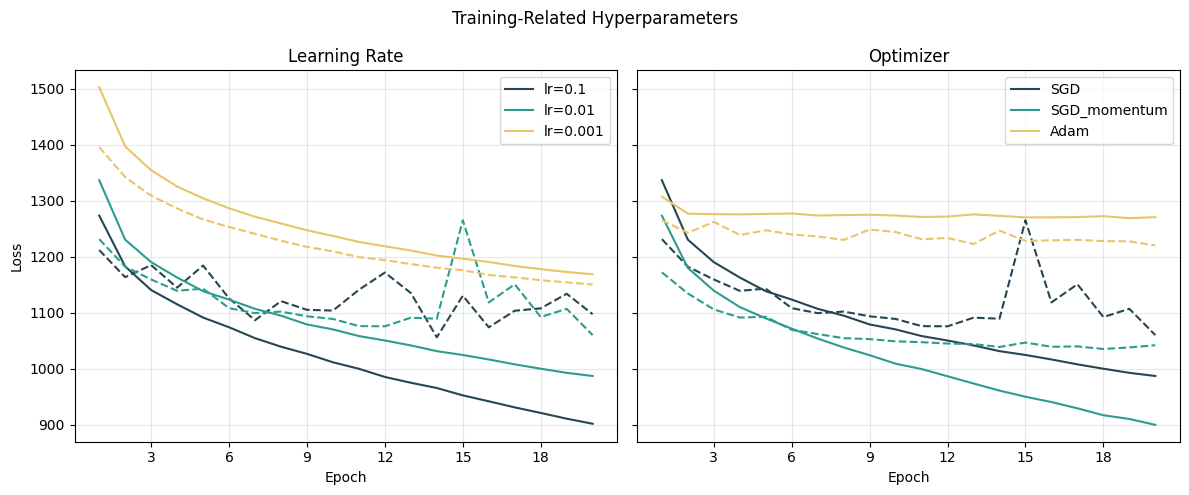

In [15]:
plot_training_params(RESULT_DIR, lr_files, opt_files, "mlp_training_param.png")

In [16]:
dropout_files = {
    "dropout=0.1": "mlp_dropout_01_history.csv",
    "dropout=0.3": "mlp_optimizer_sgd_momentum_history.csv",
    "dropout=0.5": "mlp_dropout_05_history.csv",
}

wd_files = {
    "wd=1e-2": "mlp_weight_decay_1e2_history.csv",
    "wd=1e-4": "mlp_optimizer_sgd_momentum_history.csv",  # baseline
    "wd=1e-5": "mlp_weight_decay_1e5_history.csv",
}

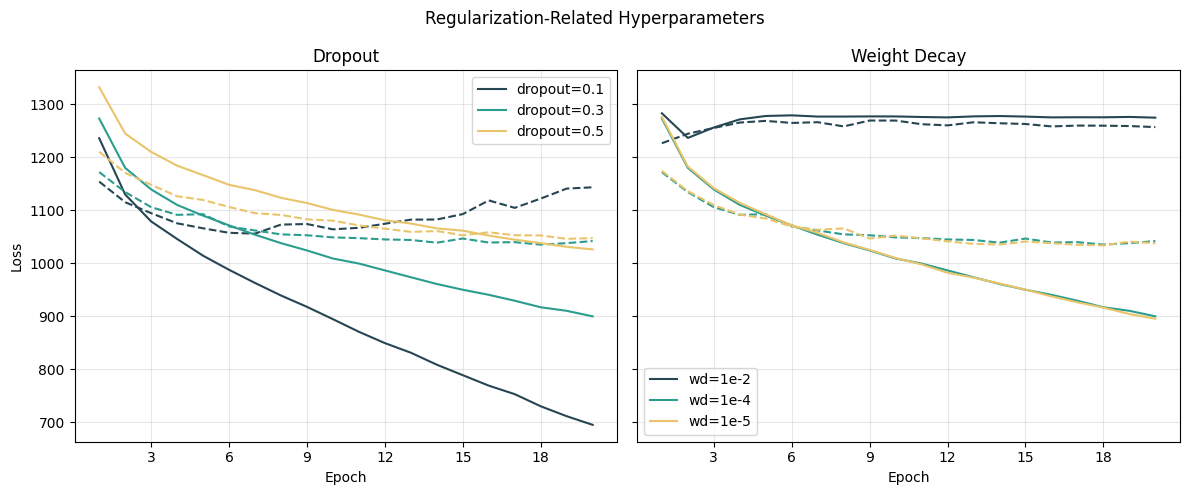

In [17]:
plot_regularization_params(RESULT_DIR, dropout_files, wd_files, "mlp_regularization_param.png")

In [24]:
da_files = {
    "blur": "mlp_augmentation_blur_history.csv",
    "color jitter": "mlp_augmentation_color_jitter_history.csv",
    "mixup": "mlp_augmentation_mixup_history.csv",
    "sobel": "mlp_augmentation_sobel_history.csv",
    "rotation": "mlp_augmentation_rotation_history.csv"
    }

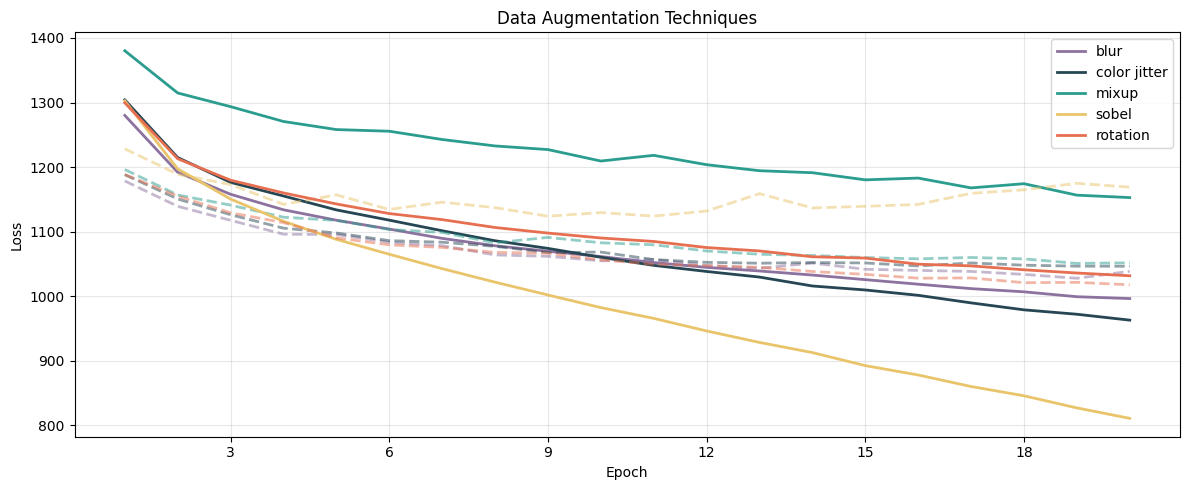

In [25]:
plot_data_augumentation(RESULT_DIR, da_files, "mlp_data_aug.png")

In [20]:
df = pd.read_csv(os.path.join(RESULT_DIR, "experiment_results.csv"))

In [21]:
df.sort_values("test_accuracy").reset_index(drop=True)

,experiment,lr,optimizer,dropout,weight_decay,augmentation,test_accuracy
0,mlp_optimizer_adam,0.010,Adam,0.3,0.00010,NaN,0.362600
1,mlp_weight_decay_1e2,0.010,SGD_momentum,0.3,0.01000,NaN,0.364622
2,mlp_lr_0.001,0.001,SGD,0.3,0.00010,NaN,0.411878
3,mlp_augmentation_sobel,0.010,SGD_momentum,0.3,0.00001,sobel,0.431756
4,mlp_lr_0.1,0.100,SGD,0.3,0.00010,NaN,0.451889
5,mlp_lr_0.01,0.010,SGD,0.3,0.00010,NaN,0.453578
6,mlp_dropout_05,0.010,SGD_momentum,0.5,0.00010,NaN,0.458456
7,mlp_dropout_01,0.010,SGD_momentum,0.1,0.00010,NaN,0.458978
8,mlp_augmentation_color_jitter,0.010,SGD_momentum,0.3,0.00001,color_jitter,0.467844
9,mlp_augmentation_mixup,0.010,SGD_momentum,0.3,0.00001,NaN,0.467956


In [22]:
df = get_final_val_acc(RESULT_DIR, [lr_files, opt_files, dropout_files, wd_files, da_files])

In [23]:
df

,file,val_acc
0,mlp_weight_decay_1e2_history.csv,0.363867
1,mlp_optimizer_adam_history.csv,0.365244
2,mlp_lr_0.001_history.csv,0.410889
3,mlp_augmentation_sobel_history.csv,0.433856
4,mlp_lr_0.1_history.csv,0.451089
5,mlp_lr_0.01_history.csv,0.456233
6,mlp_dropout_01_history.csv,0.459133
7,mlp_dropout_05_history.csv,0.459344
8,mlp_augmentation_color_jitter_history.csv,0.467400
9,mlp_augmentation_mixup_history.csv,0.469844


### Analysis for CNN

### Analysis for Mobile Net

### Analysis for Resnet 18

In [ ]:
lr_files = {
    "lr=0.1": "resnet_0.1_history.csv",
    "lr=0.01": "resnet_0.01_history.csv",
    "lr=0.001": "resnet_0.001_history.csv",
}

opt_files = {
    "SGD": "resnet_0.1_history.csv",
    "SGD_momentum": "resnet_sgd_momentum_history.csv",
    "Adam": "resnet_adam_history.csv",
}


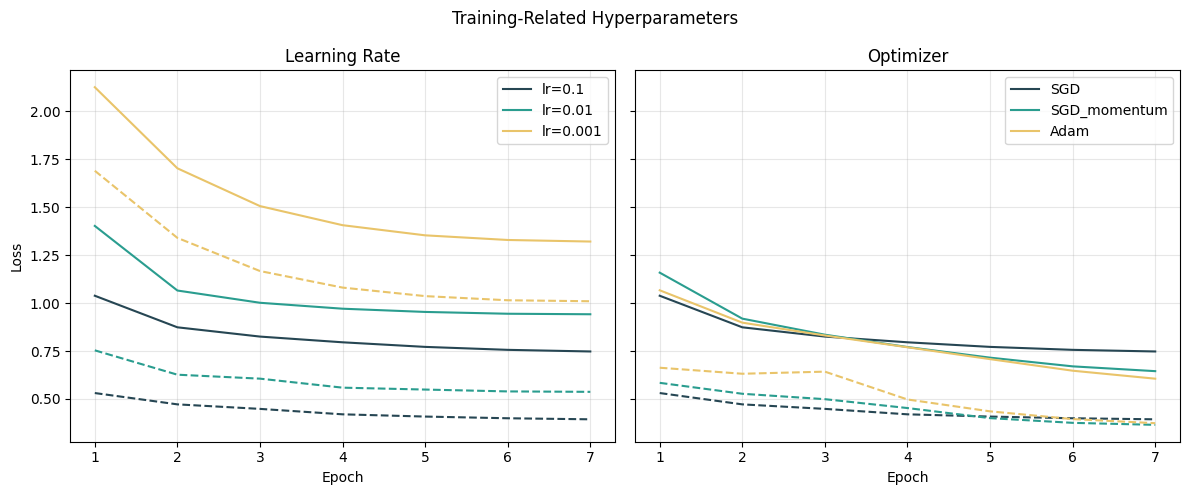

In [ ]:
plot_training_params(RESULT_DIR, lr_files, opt_files, "mlp_training_param.png")

In [ ]:
dropout_files = {
    "dropout=0.1": "resnet_dropout_0.1_history.csv",
    "dropout=0.3": "resnet_sgd_momentum_history.csv",
    "dropout=0.5": "resnet_dropout_0.5_history.csv",
}

wd_files = {
    "wd=1e-2": "resnet_weight_decay1e02_history.csv",
    "wd=1e-3": "resnet_weight_decay1e03_history.csv",
    "wd=1e-4": "resnet_sgd_momentum_history.csv",
}

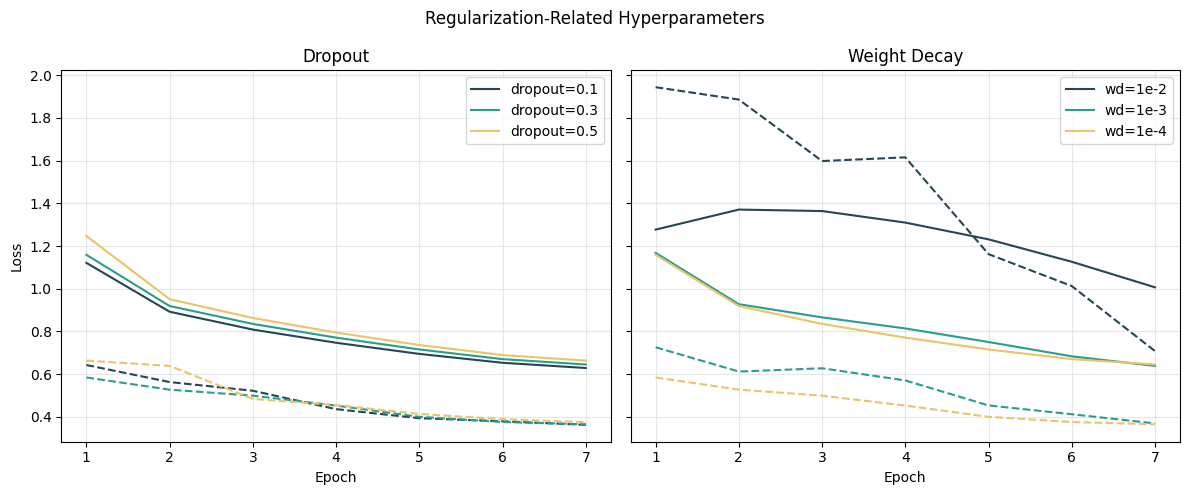

In [ ]:
plot_regularization_params(RESULT_DIR, dropout_files, wd_files, "mlp_regularization_param.png")

In [ ]:
da_files = {
    "blur": "resnet_augmentation_blur_history.csv",
    "color_jitter": "resnet_augmentation_color_jitter_history.csv",
    "mixup": "resnet_augmentation_mixup_history.csv",
    "sobel": "resnet_augmentation_sobel_history.csv",
    "rotation": "resnet_augmentation_rotation_history.csv"
    }

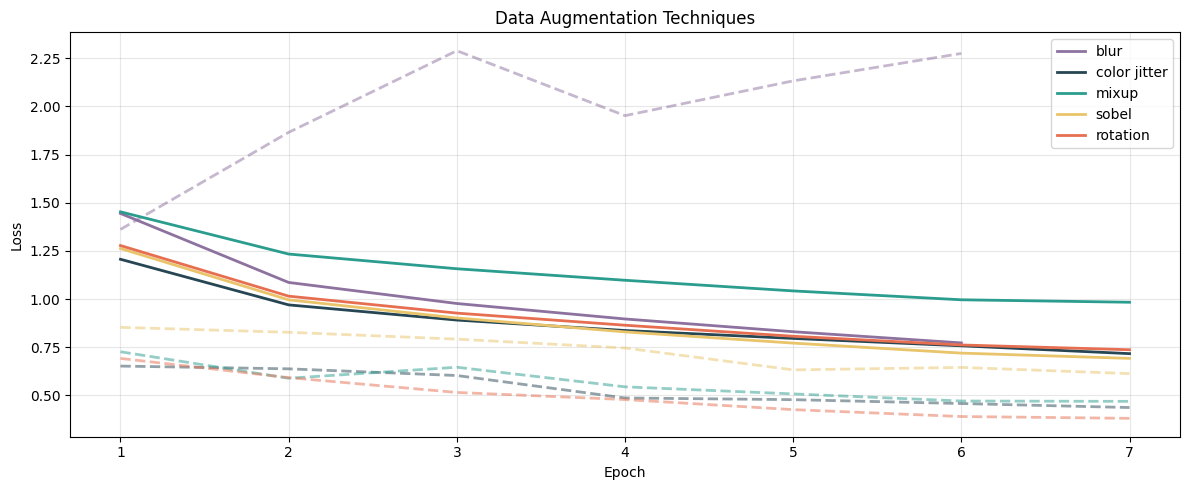

In [ ]:
plot_data_augumentation(RESULT_DIR, da_files, "mlp_data_aug.png")

In [ ]:
df = pd.read_csv(os.path.join(RESULT_DIR, "resnet_experiment_results.csv"))

In [ ]:
df.sort_values("test_accuracy").reset_index(drop=True)

,experiment,lr,optimizer,dropout,weight_decay,augmentation,test_accuracy
0,resnet_augmentation_blur,0.100,SGD_momentum,0.3,0.0001,gaussian_blur,0.2749
1,resnet_lr=0.001,0.001,SGD,0.3,0.0001,NaN,0.6784
2,resnet_wd=1e-2,0.100,SGD_momentum,0.3,0.0100,NaN,0.7738
3,resnet_augmentation_sobel,0.100,SGD_momentum,0.3,0.0001,sobel,0.8085
4,resnet_lr=0.01,0.010,SGD,0.3,0.0001,NaN,0.8326
5,resnet_augmentation_rotation,0.100,SGD_momentum,0.3,0.0001,rotation,0.8848
6,resnet_lr=0.1,0.100,SGD,0.3,0.0001,NaN,0.8853
7,resnet_augmentation_mixup,0.100,SGD_momentum,0.3,0.0001,mixup,0.8892
8,resnet_dropout=0.5,0.100,SGD_momentum,0.5,0.0001,NaN,0.8906
9,resnet_Adam,0.001,Adam,0.3,0.0001,NaN,0.8919


In [ ]:
df = get_final_val_acc(RESULT_DIR, [lr_files, opt_files, dropout_files, wd_files, da_files])

In [ ]:
df

,file,val_acc
0,resnet_augmentation_blur_history.csv,0.281011
1,resnet_0.001_history.csv,0.678678
2,resnet_weight_decay1e02_history.csv,0.776856
3,resnet_augmentation_sobel_history.csv,0.807889
4,resnet_0.01_history.csv,0.833767
5,resnet_0.1_history.csv,0.886744
6,resnet_augmentation_rotation_history.csv,0.887756
7,resnet_augmentation_mixup_history.csv,0.891200
8,resnet_dropout_0.5_history.csv,0.892167
9,resnet_adam_history.csv,0.892778
